
Patrícia Daniela Fernandes Bastos - a102502

Cláudia Rego Faria - a105531

# **3-SAT Problem**


The 3-Satisfiability Problem (3-SAT) is a classic problem in computational complexity theory and an
important example of an NP-complete problem. It asks whether an assignment of boolean variables
exists that satisfies a given boolean formula. The formula is expressed in conjunctive normal form
(CNF), where each clause contains exactly three literals. A literal is a boolean variable or its negation,
and a clause is a disjunction (logical OR) of literals. The entire formula is a conjunction (logical AND)
of these clauses. Consider the Boolean formula below:

$$F = (x1 ∨ x2 ∨ x3) ∧ (¬x1 ∨ ¬x2 ∨ x3) ∧ (x1 ∨ ¬x2 ∨ ¬x3)$$

In this formula, each clause is enclosed in parentheses and contains exactly three literals combined
using the logical OR operator $∨$. The entire formula $F$ is a conjunction of these clauses combined using the logical AND operator $∧$.

The goal is to determine whether an assignment of truth values (true or false) exists to the variables $x_1, x_2, x_3$ such that the entire formula $F$ evaluates to true. This involves checking all possible combinations of truth values for the variables and identifying those that satisfy all the clauses
simultaneously.

## 1. Propose a solvable 3-SAT boolean formula.


$F=(x1​∨¬x2​∨x3​)∧(¬x1​∨¬x2​∨x3​)∧(x1​∨x2​¬∨x3​)∧(¬x1​¬∨x2​∨¬x3​)∧(x1​∨x2​∨x3​)∧(¬x1​∨x2​∨x3​)∧(¬x1​∨x2​¬∨x3​)$


## 2. Implement Grover's algorithm to find a solution.


In [30]:
import pennylane as qml
from pennylane import numpy as np


In [31]:
def grover(n_qubits, iterations="optimal"):

    #create registers
    input_registers = range(n_qubits)

    #superposition
    qml.broadcast(qml.Hadamard, wires=input_registers, pattern="single")

    qml.Barrier()

    if iterations == "optimal":
        its = int(np.round(np.pi/4*np.sqrt(2**n_qubits)))
    else:
        its = iterations

    for _ in range(its):
        #oracle
        
        qml.PauliX(wires=input_registers[1])
        qml.ControlledQubitUnitary(qml.PauliZ(input_registers[-1]), control_wires=input_registers[:-1])
        qml.PauliX(wires=input_registers[1])

        qml.Barrier()

        qml.PauliX(wires=input_registers[0])
        qml.PauliX(wires=input_registers[1])
        qml.ControlledQubitUnitary(qml.PauliZ(input_registers[-1]), control_wires=input_registers[:-1])
        qml.PauliX(wires=input_registers[0])
        qml.PauliX(wires=input_registers[1])

        qml.Barrier()

        qml.PauliX(wires=input_registers[2])
        qml.ControlledQubitUnitary(qml.PauliZ(input_registers[-1]), control_wires=input_registers[:-1])
        qml.PauliX(wires=input_registers[2])

        qml.Barrier()

        qml.PauliX(wires=input_registers[0])
        qml.PauliX(wires=input_registers[1])
        qml.PauliX(wires=input_registers[2])
        qml.ControlledQubitUnitary(qml.PauliZ(input_registers[-1]), control_wires=input_registers[:-1])
        qml.PauliX(wires=input_registers[0])
        qml.PauliX(wires=input_registers[1])
        qml.PauliX(wires=input_registers[2])

        qml.Barrier()

        qml.ControlledQubitUnitary(qml.PauliZ(input_registers[-1]), control_wires=input_registers[:-1])

        qml.Barrier()

        qml.PauliX(wires=input_registers[0])
        qml.ControlledQubitUnitary(qml.PauliZ(input_registers[-1]), control_wires=input_registers[:-1])
        qml.PauliX(wires=input_registers[0])

        qml.Barrier()

        qml.PauliX(wires=input_registers[0])
        qml.PauliX(wires=input_registers[2])
        qml.ControlledQubitUnitary(qml.PauliZ(input_registers[-1]), control_wires=input_registers[:-1])
        qml.PauliX(wires=input_registers[0])
        qml.PauliX(wires=input_registers[2])

        qml.Barrier()
        
        #diffusion
        for wire in input_registers:
            qml.Hadamard(wires=wire)
        
        for wire in input_registers:
            qml.PauliX(wires=wire)
        
        qml.ControlledQubitUnitary(qml.PauliZ(input_registers[-1]), control_wires=input_registers[:-1])
        
        for wire in input_registers:
            qml.PauliX(wires=wire)
        
        for wire in input_registers:
            qml.Hadamard(wires=wire)
        
        qml.Barrier()


    #measurement
    return qml.probs(wires=input_registers)

(<Figure size 3700x400 with 1 Axes>, <Axes: >)

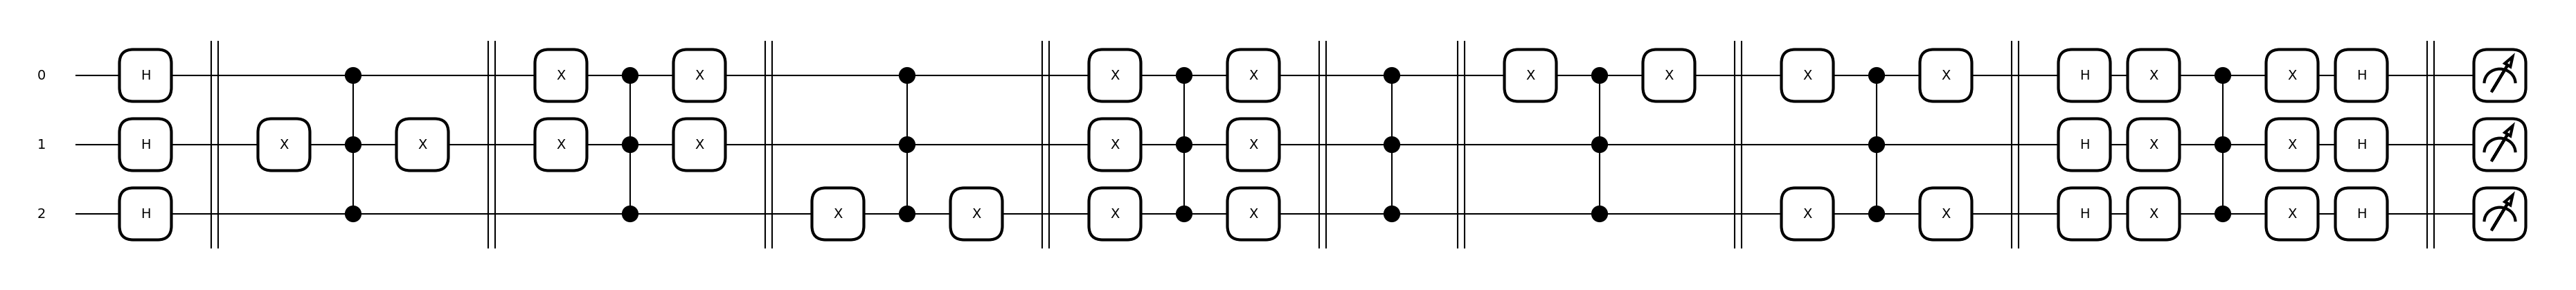

In [32]:
n_qubits = 3
itarations = 1

dev = qml.device("default.qubit")#, wires=n_qubits)

Grover = qml.QNode(grover, dev)

probs = Grover(n_qubits, iterations=itarations)

qml.draw_mpl(Grover)(n_qubits, iterations=itarations)

Text(0.5, 1.0, 'Probability Distribution')

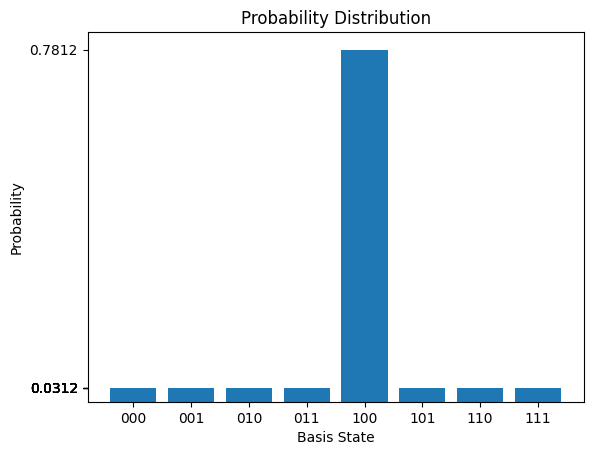

In [33]:
#Visualize the probability histogram
import matplotlib.pyplot as plt
plt.bar([np.binary_repr(i, width=n_qubits) for i in range(2**n_qubits)], probs)

plt.xlabel("Basis State")
plt.ylabel("Probability")
plt.yticks(probs)
plt.title("Probability Distribution")

## 3. Assess the algorithm's efficiency in finding a solution.

If we used a classical search to find a satisfying assignment to this problem, a classical brute-force algorithm would have to check up to $2^n$ possibilities. In this case, with $n = 3$, that would mean 8 possibilities.

Grover's quantum search reduces the number of queries to the oracle to approximately $\sqrt{2^n}$, which is more or less just 2 iterations. As expected from Grover's Algorithm, we see a quadratic speedup over classical brute-force.

Overall, for small values of $n$, using Grover's Algorithm doesn't provide that many advantages. The algorithm provides a quadratic speedup which is helpful for larger values of $n$. It's important to note that, with our implementation, the oracle's need to be constructed can become a nuisance.